# Illustrating the generalized central limit theorem

## References

- https://www.stat.ubc.ca/~saif.syed/papers/PMATH_800_paper.pdf
- https://www.cs.toronto.edu/~yuvalf/CLT.pdf

## Thoughts

> the normalized sums do not converge uniformly to a normal distribution. This means that the tails of the distribution converge more slowly than its center. Estimates for the speed of convergence are given by the Berry-Ess´een theorem and Chernoff’s bound.

## Introduction

Whoever has computed sums of random variables knows that they have a tendency to become normal - under certain conditions. This behaviour is summed up in the central limit theorem and is one primary reason for the exceptional position that the normal distribution takes. It is an _attractor_ for distributions.

In [1]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sympy as sp
from IPython.display import display
sns.set_theme()

In [2]:
dt = 0.1
nyq = 2/dt
x = np.arange(-1000, 1000, dt)
f = np.fft.fftshift(np.fft.fftfreq(n=len(x))) * nyq

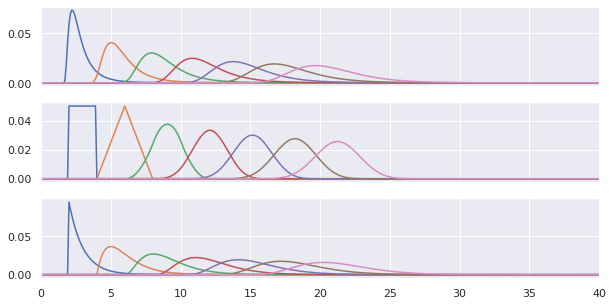

In [3]:
dists = [stats.lognorm.pdf(x, loc=np.log(5), s=np.log(2)),
         stats.uniform.pdf(x, loc=2, scale=2),
         stats.expon.pdf(x, loc=2, scale=1)]

ndists = len(dists)
fig, axes = plt.subplots(ndists, 1, figsize=(10, 5), sharex=True)
for ax, dist in zip(axes, dists):
    acc = [1.0]
    scanned = [acc := np.convolve(acc, x, "same") for x in [dist]*7]
    for scan in scanned:
        ax.plot(x, scan/scan.sum())
ax.set(xlim=(0, 40));

## Convolutions in the Fourier domain

The convolution of functions becomes much easier to grasp when using characteristic functions, the Fourier transform of a distribution. It can be computed numerically with the Fast Fourier Transformation (FFT). Here is the characteristic function of a simple uniform distribution:

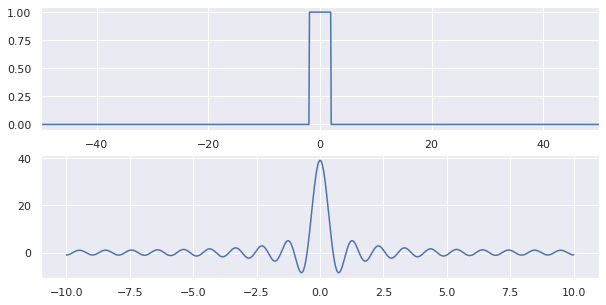

In [4]:
y = np.zeros_like(x); y[:20] = 1; y[-19:] =1
Y = np.fft.fftshift(np.fft.fft(y))

fig, (ax1, ax2) = plt.subplots(2, figsize=(10, 5))
ax1.plot(x, np.fft.fftshift(y))
ax1.set(xlim=(-50, 50))
ax2.plot(f, np.real(Y));

As a quick reminder: length scales are essentially inverted in the Fourier transform. The large scale behaviour of the distribution is determined by frequencies close to zero, and small scale fluctuations by frequencies with high absolute value. For example, the little wiggles you see mostly determine the sharp edges of the uniform distribution whereas the central peak determines where its principal is.
The imaginary part of the characteristic function is zero because the distribution is symmetric, which is why we don't plot it (yet).

Let's have a look what happens to the distribution and the characteristic function if we start convolving the distribution with itself.In the Fourier domain this simply means multiplying the spectrum with itself, and since it is a real number this is quite easy.

[(-1.0, 1.0)]

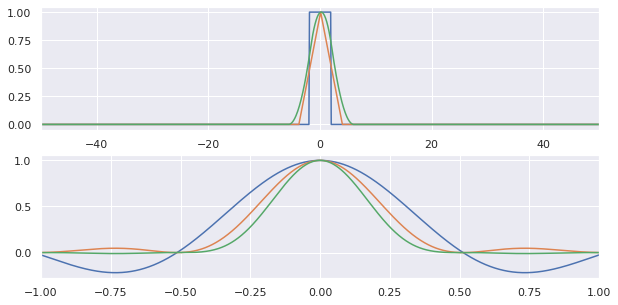

In [5]:
nconvolutions = 3
acc = [1.0]; scanned1 = [acc := np.convolve(acc, np.fft.fftshift(e), "same") for e in [y]*nconvolutions]
ACC = np.ones_like(Y); scanned2 = [ACC := ACC * e for e in [Y]*nconvolutions]

fig, (ax1, ax2) = plt.subplots(2, figsize=(10, 5))
for s, S in list(zip(scanned1, scanned2)):
    snorm, Snorm = s/s.max(), S / np.abs(S).max()
    ax1.plot(x, snorm)
    ax2.plot(f, np.real(Snorm))
ax1.set(xlim=(-50, 50))
ax2.set(xlim=(-1, 1))

In only three iterations the distribution and its characteristic function closely resemble a Gaussian.
How did this happen magically?

One property that _all_ characteristic functions have is a central peak at frequency $0$ with value $1$. This is because the value of the characteristic function at zero frequency, corresponding to a flat cosine with infinite wavelength, is simply the norm of the distribution. All other absolute values of characteristic function are smaller than one. An intuitive, hand-wavy explanation for what happens is thus that, when multiplying the spectrum with itself over and over again, smaller values decay faster than larger ones, and after a few iterations, only the central peak survives that is close to 1.
And this peak somewhat resembles a Gaussian.
So far so good, but why does this central peak look more and more like a Gaussian?
Could it look like something else in specific cases?

The key to understanding the relationship between the exponential function and  taking something to the infinite power is the identity:

$$
e^{x} = \sum_{k=0}^\infty \frac{x^k}{k!} = \lim_{n \rightarrow \infty} (1 + \frac{x}{n})^n
$$

In fact, this identity can be expanded even further, adding terms inside of the sum that decay fast than $O(\frac{1}{n})$.

$$
e^{x} = \sum_{k=0}^\infty \frac{x^k}{k!} = \lim_{n \rightarrow \infty} (1 + \frac{x}{n} + O(\frac{1}{n^2}))^n
$$

Now, the crucial insight is that _only_ the $\frac{1}{n}$ term survives the limit.
The reason is that, after expanding, the factor before a summand of order $(\frac{x}{n})^n$ grows with $n^n$ thus converging to a non-zero constant. The actual factor is $\frac{n!}{k! (n-k)!}$, and if you have difficulties imagining this checkout the expanded version [here](https://en.wikipedia.org/wiki/Binomial_theorem). Anything in the sum that decays faster in $n$ than $\frac{1}{n}$ vanishes in this limit. Adapted to a Gaussian this looks like:

$$
e^{-x^2} = \lim_{n \rightarrow \infty} (1 - \frac{x^2}{n} + O(\frac{1}{n^2}))^n
$$

The form $1 - \frac{x^2}{n}$ should make you curious if you have ever computed maxima of functions.
This is simply the local approximation to _any_ function around a (well behaved) peak at value $1$, and the beginning of its full Taylor series which also has higher orders.

Now we can piece together what happens with the characteristic function.
Every time we multiply a characteristic function with itself, or from a different perspective its Taylor series around the central peak, all terms in this series except for the zeroth ($=1$) order, the second term $=x^2/n^2$ get smaller.

## A concrete example: The central limit theorem on a uniform distribution

A look at the actual equations might be insightful here.
Consider a uniform distribution $U$ with width $2$ and variance $\frac{1}{3}$.
After $n$ convolutions of the uniform distribution with itself, it will gradually converge to a normal distribution with variance $\frac{n}{3}$.
Since this variance blows up for large $n$, we will look at convolving distributions $U$ with width $2/\sqrt{n}$ instead.
These distributions will always converge to the same normal distribution with fixed variance $\sigma^2 = \frac{1}{3}$.
The characteristic function of these uniform distributions is the _sinc_ function and can be written as:

$$\textrm{sinc}(t / \sqrt{n}) = \frac{\sin(t / \sqrt{n})}{t / \sqrt{n}}$$

It has the property $\textrm{sinc}(0) = 1$, as it should as every characteristic function.
In contrast to the distribution that become narrower and narrower, this function becomes wider and wider before convolution and will converge to the characteristic function of a fixed normal distribution - a Gaussian bell curve - with characteristic function $\exp{(-\sigma^2t^2/2)}$.
The Taylor series of this function is:

$$\textrm{sinc}(t / \sqrt{n})= 1 - \frac{t^{2}}{6n} + \frac{t^{4}}{120n^2} - \frac{t^{6}}{5040n^3} + O\left(\frac{t^{8}}{n^4}\right)$$

With a little trick we can bring this in the $(1 + x/n)$ form to connect it with the exponential:

$$= 1 - \frac{\frac{t^{2}}{6} - \frac{t^{4}}{120n} + \frac{t^{6}}{5040 n^2} + O\left(\frac{t^{8}}{n^3}\right)}{n}$$

We can introduce a new variable $x^\prime$ as follows:

$$
x^\prime = \frac{x^{2}}{6} - \frac{x^{4}}{120n} + \frac{x^{6}}{5040n^2} + O\left(\frac{x^{8}}{n^3}\right) \xrightarrow{n \rightarrow \infty} \frac{x^2}{6} = \frac{\sigma^2 x^2}{2}
$$

In this form, with a new variable, we can easily tackle the limit, and get:

$$
\lim_{n \rightarrow \infty} (\textrm{sinc}(\frac{x}{\sqrt{n}}))^n = \lim_{n \rightarrow \infty} (1 - \frac{x^\prime}{n})^n = e^{-\frac{x^2}{6}} = e^{-\frac{\sigma^2 x^2}{2}}
$$

This is exactly the characteristic function of a normal distribution with standard deviation $2\sigma$, which is what we wanted to show.

## Asymmetric distributions and complex valued characteristic functions

Let's consider something more interesting: a bimodal, asymmetric distribution.
In principle, the only thing that is changing here is that the characteristic function is now complex valued, but the above equations still hold and can be used to make the connection.
Although the intuition for convergence of the magnitude of the complex function is quite similar to what we have discussed, the intuition for the phase, or imaginary part is not.
Essentially an asymmetric function ends up being a symmetric normal distribution with imaginary part zero if it is centered around the mean which feels strange.
This is what we are looking at in this section.

[(-100.0, 100.0)]

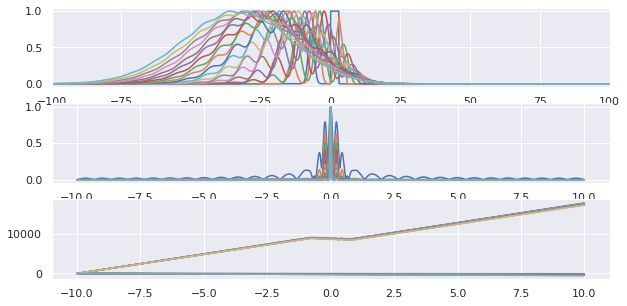

In [6]:
y = 0.5 * stats.norm.pdf(x, loc=-7, scale=1) + 0.8 * stats.uniform.pdf(x, loc=0, scale=3)
Y = np.fft.fftshift(np.fft.fft(y))

acc = [1.0]
scanned1 = [acc := np.convolve(acc, e, "same") for e in [y]*20]

ACC = np.ones_like(Y)
scanned2 = [ACC := ACC * e for e in [Y]*20]

fig, (ax1, ax2, ax3) = plt.subplots(3, figsize=(10, 5))

for s, S in list(zip(scanned1, scanned2))[::]:
    snorm, Snorm = s/s.max(), S / np.abs(S).max()
    ax1.plot(x, snorm)
    ax2.plot(f, np.abs(Snorm))
    ax3.plot(f, np.unwrap(np.angle(Snorm))/np.pi)
    
ax1.set(xlim=(-100, 100))

In the above plot, we show now the distribution (row 1), the magnitude of the characteristic function (row 2), and the phase of the characteristic function (row 3) for a set of convolved functions. We can clearly see how the distribution and magnitude converge to a Gaussian as before. What is more interesting is the phase of the characteristic function which clearly seems to level around frequency zero indicating that the distribution is becoming symmetric.


An alternative way to show this function is in the 2D complex plane:

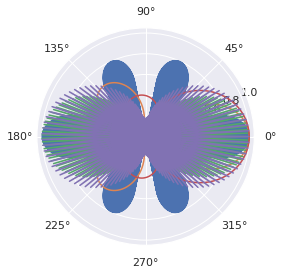

In [7]:
fig, ax = plt.subplots(subplot_kw={"projection": "polar"})
for s, S in list(zip(scanned1, scanned2))[:5]:
    Snorm = S / np.abs(S).max()
    ax.plot(np.angle(Snorm), np.abs(Snorm))

What is going on here?
First, you can see that the initial function (blue) spins around quite wildly in the complex plane.
Later iterations successively become rounder.

There are different perspectives that we can take on this.
As we previously emphasized that each convolution succesively zooms in to the region around the peak of the characteristic function, similarly in this plot the outer most part that is close to the maximum gets “blown” up because it decays least when multiplied with itself. Over time it'll thus dominate.
But then, in addition, the outer most ring gets slowly pulled into circular shape as the phases add up.
Circular shape in the complex domain relates to $e^{it\mu}$ which is a factor generated by a non-zero $\mu$.

We can further decompose the complex multiplications step by step with arrows showing how points get rotated and scaled at a multiplication:

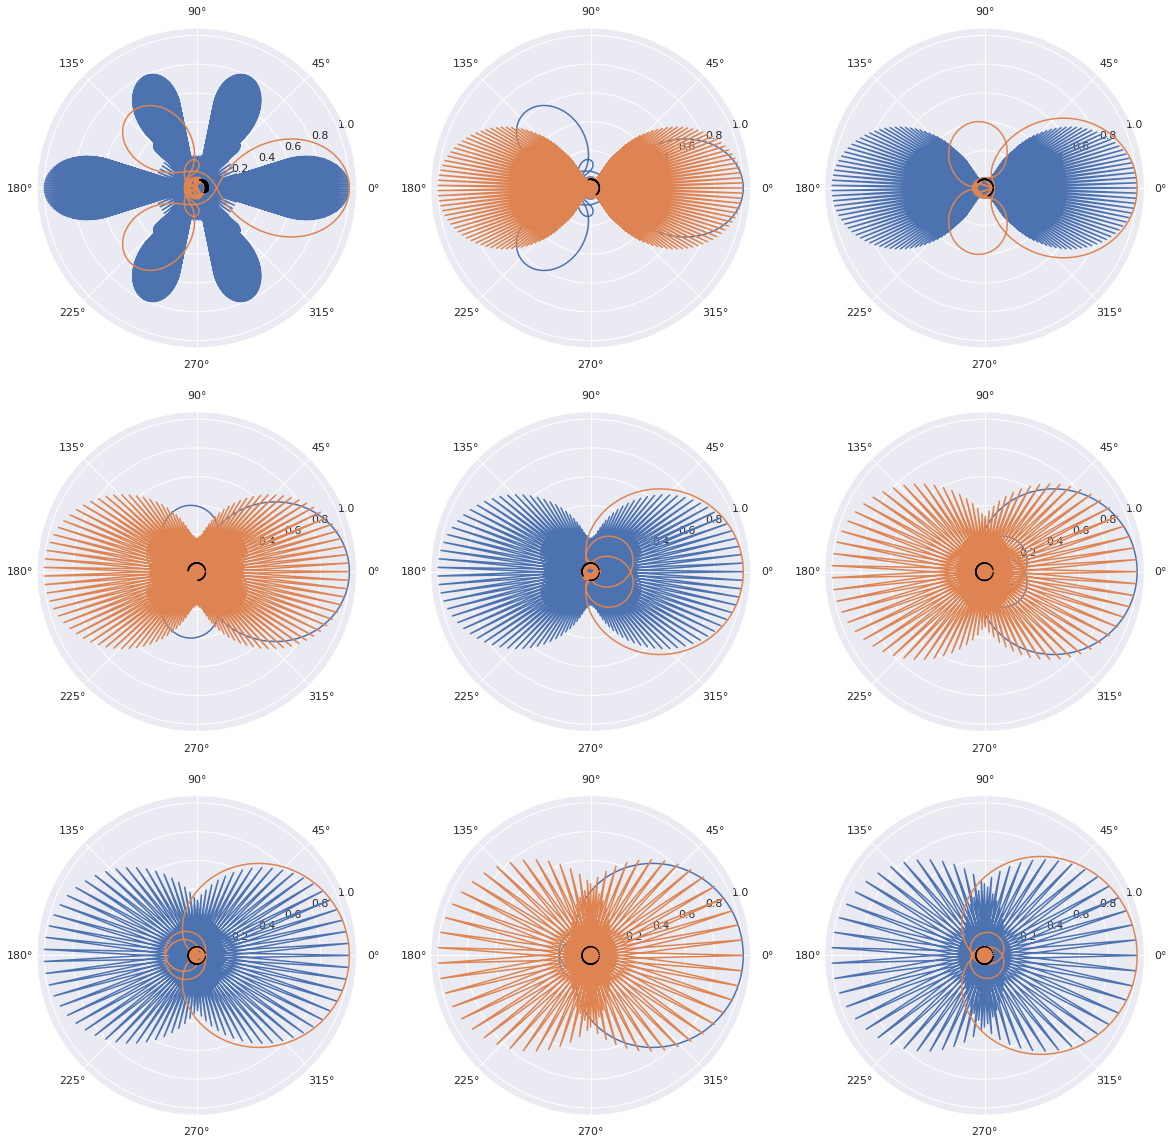

In [8]:
Snorms = [s / np.abs(s).max() for s in scanned2]

diffs = []
for s1, s2 in zip(Snorms, Snorms[1:]):
    diffA = np.angle(s2) - np.angle(s1) # [npoints]
    mask = diffA>np.pi # turn that is larger than a demi circle
    diffA[mask] = -(2*np.pi - diffA[mask])
    mask = diffA<-np.pi
    diffA[mask] = (2*np.pi + diffA[mask])
    diffR = np.abs(s2) - np.abs(s1) # [npoints]
    angles = np.angle(s1)[:, None] + np.linspace(0., 1., 100)[None, :] * diffA[:, None]
    radii = np.abs(s1)[:, None] + np.linspace(0., 1., 100)[None, :] * diffR[:, None]
    diffs.append((angles, radii))


fig, axes = plt.subplots(3, 3, figsize=(20, 20), subplot_kw={"projection": "polar"})
for ispec,ax in zip(range(0, 15), axes.flatten()):
    ax.plot(np.angle(Snorms[ispec]), np.abs(Snorms[ispec]))
    ax.plot(np.angle(Snorms[ispec+1]), np.abs(Snorms[ispec+1]))
    for ipoint in range(900, 1100, 6):
        angles, radii = diffs[ispec]
        ax.plot(angles[ipoint], radii[ipoint], c="black");
        l = 2
        dtheta = angles[ipoint, -1] - angles[ipoint, -l]
        dr =  radii[ipoint, -1] - radii[ipoint, -l]
        ax.arrow(angles[ipoint, -l], radii[ipoint, -l], dtheta, dr, head_length=0.03, overhang=0.01, head_width=0.02,
                 length_includes_head=True, color="black")

The size of the loop is actually determined by the mean of the Gaussian that the distribution is converging to: a larger loop means a larger shift. Note that at every iteration in the above plot, every point gets scaled and rotated by the same amount, basically based on their initial position. This explains how the whole system gradually comes to a halt: points that are closest to the peak move slowest and, as the whole ring, slowly decays, they are the only ones left so that the system is converging slower and slower.

Again, the precise behaviour around the 0 peak determines the large scale behaviour of the distribution. Higher frequencies get quickly lost in the convolution process. This is not a general necessity but a consequence of using rather smooth, positive-semidefinite functions that we convolve with in statistics. Intuitively, these functions always smooth the other function and can never do the opposite, roughen it up. For that we would need to convolve with a strongly oscillating function.

## Generalized Central Limit Theorem and Power Laws

What if we consider distributions with _infinite_ variance or mean.
Such distributions sound crazy but actually occur quite often.
Two central thoughts are important to understand the behaviour of the generalized central limit theorem: $x^\alpha \propto \omega^{-(\alpha + 1)}$  says that a power law in the time domain corresponds to a power law with negative and increased by one exponent in the Fourier domain.

For example, a straight line (exponent $\alpha=1$) in time domain corresponds to a square decay (exponent $\beta=-2$) in Fourier domain,
and a $1/x$ decay (exponent $\alpha=-1$) corresponds to a constant spectrum in Fourier domain.
The point of equilibrium is reached at $\alpha=0.5$ where $\beta=0.5$ as well - a special place which corresponds to pink noise or even power per log unit such as decibel or octave.

In addition to this, it is important to remember that length scales in Fourier space are inverted: _low_ frequency determine the large scale changes and _high_ frequencies the short scale behaviour.
To understand, for example, the large scale asymptotic behaviour of a function from its Fourier transform, we need to look at its behavior around 0 - something we will do extensively in this article.

Consider for example the following function that falls of with exponent $\alpha=-2$, corresponding to $\beta=1$ in Fourier domain.
Careful, you might expect the Fourier spectrum to _rise_ with frequency, but it could equally fall as in $-f$ and in addition it could be shifted by a constant $c - mf$. All the above equation says is that the square dropoff in time at large scale should correspond to a _linear_ bahviour of the spectrum at _low_ frequencies.

Equipped with these warning let's have a look:

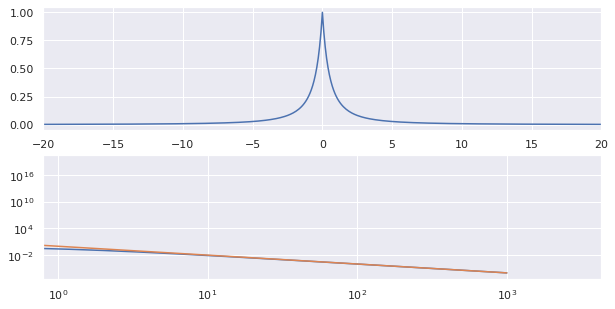

In [9]:
y = 1./(1 + np.abs(x)) ** 2

fig, (ax1, ax2) = plt.subplots(2, figsize=(10, 5))
ax1.plot(x, y)
ax1.set(xlim=(-20, 20))
ax2.plot(x[x>0], y[x>0])
ax2.plot(x[x>0], x[x>0]**-2)
ax2.set(xscale="log", yscale="log", xlim=(0.8, None));

As expected.
Let's have a look at the spectrum:

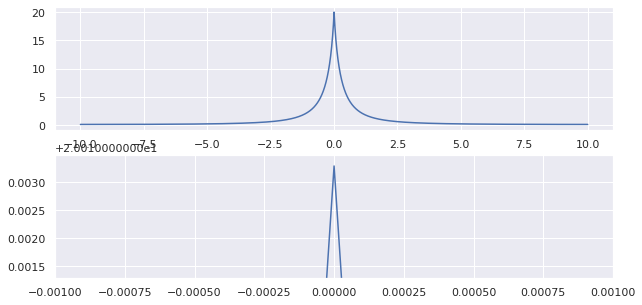

In [10]:
Y = np.real(np.fft.ifftshift(np.fft.fft(np.fft.fftshift(y))))

fig, (ax1, ax2) = plt.subplots(2, figsize=(10, 5))
ax1.plot(f, Y)
ax1.set()
ax2.plot(f, Y)
ax2.plot(f[f>0], Y[Y.argmax()] - 20*f[f>0])
ax2.plot(f[f<0], Y[Y.argmax()] + 20*f[f<0])
ax2.set(xlim=(-1e-3, 1e-3), ylim=(Y.max()*0.9999, Y.max()*1.00001));

Also as expected!
Although it is always somewhat difficult to judge asymptotic behaviour with numeric computations because of the limited level, it does look like our spectrum is converging _not_ as a parabola locally but rather linearly with a sharp edge and therefore an infinite second derivative.

What happens if I convolve this function with itself?
Essentially what we are doing is to compute:

$$\lim_{n \rightarrow \infty} (1-cf^{\alpha})^n = \lim_{n \rightarrow \infty} (1 - c \frac{(n^{1/\alpha}f)^{\alpha}}{n})^n = \lim_{n \rightarrow \infty} (1 - c \frac{z^{\alpha}}{n})^n=e^{-c z^\alpha}$$

Where $z=n^{1/\alpha}f$ is a rescaled frequency that reflects the fact that the distribution becomes wider and wider, and the spectrum narrower and narrower as we convolve. No matter _how_ the peak at 0 looks like precisely, the distribution will converge to an exponential, as long as $0<\alpha<2$.

Which can be expressed as an exponential as we already know:
Let's have a look at this:

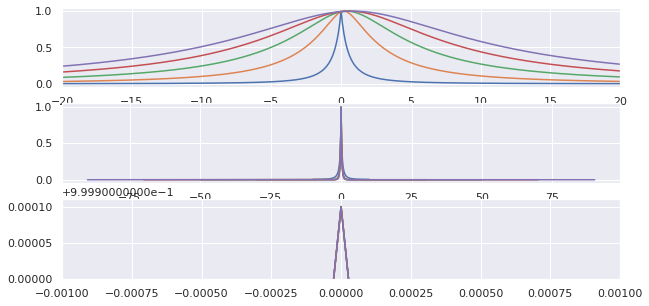

In [11]:
acc = [1.0]
scanned1 = [acc := np.convolve(acc, e, "same") for e in [y]*10]

ACC = np.ones_like(Y)
scanned2 = [ACC := ACC * e for e in [Y]*20]

fig, (ax1, ax2, ax3) = plt.subplots(3, figsize=(10, 5))

for iconv, s, S in list(zip(range(1, 20), scanned1, scanned2))[::2]:
    snorm, Snorm = s/s.max(), S / np.abs(S).max()
    ax1.plot(x, snorm)
    ax2.plot(f * iconv, Snorm)
    ax3.plot(f * iconv, Snorm)
    
ax1.set(xlim=(-20, 20))
ax3.set(xlim=(-1e-3, 1e-3), ylim=(0.9999, 1.00001));

Now, what is interesting is, that _any_ function with this behaviour can converge, as we have already seen, even if there are extra terms.
Let's have a look at some examples.

The first function we will look at is a completely arbitrarily constructed one.

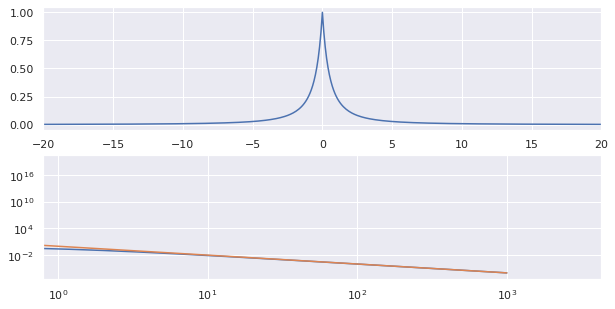

In [12]:
y = 1./(1 + np.abs(x)) ** 2

fig, (ax1, ax2) = plt.subplots(2, figsize=(10, 5))
ax1.plot(x, y)
ax1.set(xlim=(-20, 20))
ax2.plot(x[x>0], y[x>0])
ax2.plot(x[x>0], x[x>0]**-2)
ax2.set(xscale="log", yscale="log", xlim=(0.8, None));

# Auxiliary calculations

## Stable spectra around 0 peak

In [7]:
xs = sp.symbols("x")
fs = sp.exp(-abs(xs)**(1.4))

display(fs)
display(sp.series(fs, xs, x0=0, n=2.00001))

exp(-Abs(x)**1.4)

1 - x**1.4 + O(x**2.00001)

$e^{-|x|^{3/2}} = 1 - |x|^{3/2} + \frac{|x|^{6/2}}{2} - \frac{|x|^{9/2}}{6} +O\left(|x|^{10/2}\right)$

Therefore

$alpha = -3/2-1 = -5/2 = -2.5$

[(-0.25, 0.25)]

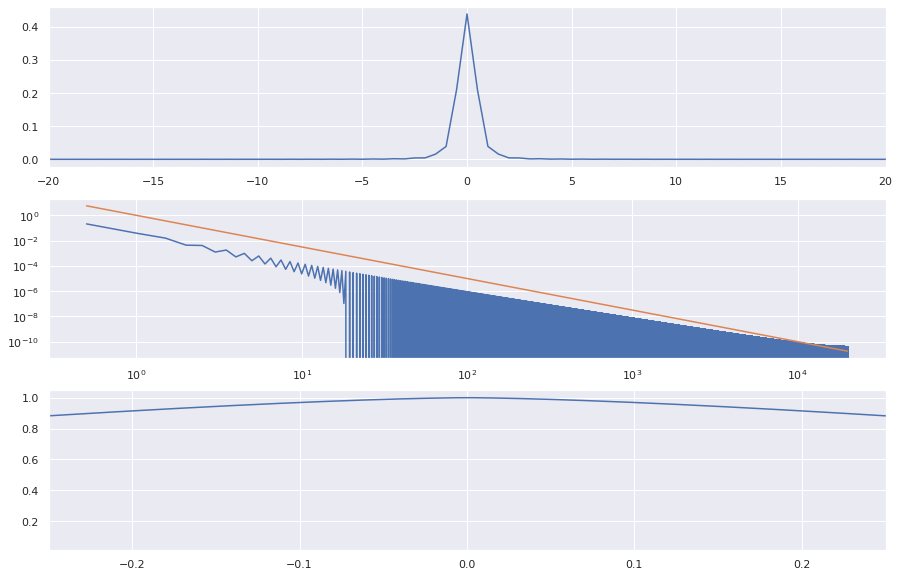

In [8]:
Y = np.exp(-np.abs(f)**(1.5))
y = np.fft.ifftshift(np.fft.ifft(np.fft.ifftshift(Y)))

fig, (ax1, ax2, ax3) = plt.subplots(3, figsize=(15, 10))
ax1.plot(x, np.real(y))
ax1.set(xlim=(-20, 20));
ax2.plot(x[x>0], np.real(y[x>0]))
ax2.plot(x[x>0], x[x>0]**-2.5)
ax2.set(xscale="log", yscale="log")

ax3.plot(f, Y)
ax3.set(xlim=(-0.25, 0.25))

[(-0.25, 0.25)]

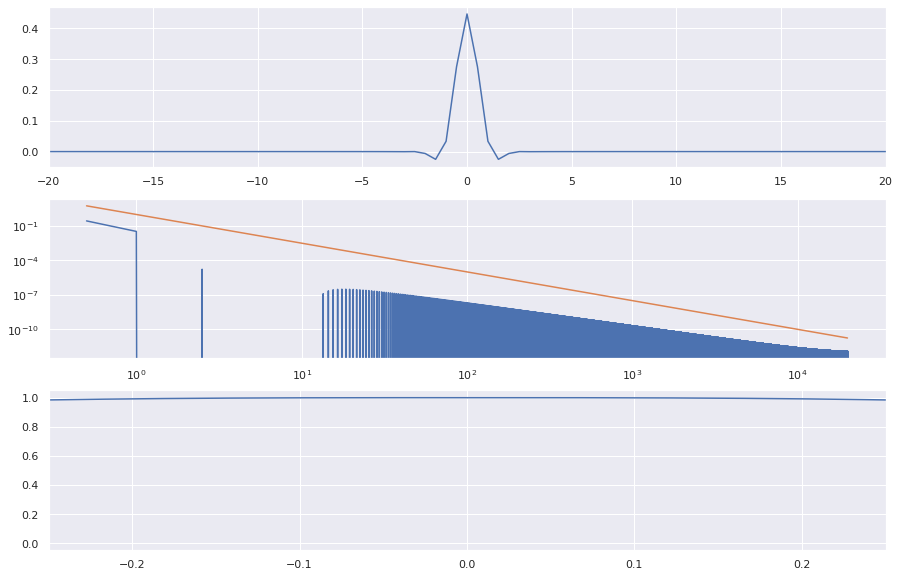

In [9]:
Y = np.exp(-np.abs(f)**(3))
y = np.fft.ifftshift(np.fft.ifft(np.fft.ifftshift(Y)))

fig, (ax1, ax2, ax3) = plt.subplots(3, figsize=(15, 10))
ax1.plot(x, np.real(y))
ax1.set(xlim=(-20, 20));
ax2.plot(x[x>0], np.real(y[x>0]))
ax2.plot(x[x>0], x[x>0]**-2.5)
ax2.set(xscale="log", yscale="log")

ax3.plot(f, Y)
ax3.set(xlim=(-0.25, 0.25))

# Auxiliary Calculations

## series of sinc

In [13]:
from sympy import symbols
from sympy import series, sinc, oo, sqrt, diff
from IPython.display import display

x = symbols("x")
f = sinc(x)
for i in range(1, 4, 1):
    display(((series(f, x, x0=0, n=8))**i).subs(x, x/sqrt(i)).expand())

1 - x**2/6 + x**4/120 - x**6/5040 + O(x**8)

1 - x**2/6 + x**4/90 - x**6/2520 + O(x**8)

1 - x**2/6 + 13*x**4/1080 - 41*x**6/81648 + O(x**8)

In [14]:
f = sinc(x**(2/3))
display(diff(f))
for i in range(1, 4, 1):
    display(((series(f, x, x0=0, n=8))**i).subs(x, (x)**(2/3)/sqrt(i)).expand())

0.666666666666667*(-sin(x**0.666666666666667)/x**1.33333333333333 + cos(x**0.666666666666667)/x**0.666666666666667)/x**0.333333333333333

sin(x**0.444444444444444)/x**0.444444444444444

1.5874010519682*sin(0.7937005259841*x**0.444444444444444)**2/x**0.888888888888889

3.0*sin(0.693361274350635*x**0.444444444444444)**3/x**1.33333333333333